# Using Gambit with SageMath: extensive form games

A strategic form game is a table of payoffs. An **extensive form game** is a tree: players move in sequence, chance may intervene, and a player may be unable to tell apart the situations they find themselves in.

SageMath's `ExtensiveFormGame` is a thin layer over Gambit's tree games. The tree itself, the information sets, and the equilibrium solvers are all Gambit's; what Sage adds is its own notation, exact rational arithmetic, plotting, and the rest of a computer algebra system.

This tutorial builds a few trees, walks through the interface, and ends with a puzzle that can be solved only by Sage.

The companion tutorial [Using Gambit with SageMath: strategic form games](sagemath_normal_form.ipynb) covers `NormalFormGame` and the strategic form interface.

> **Requirements.** As for the companion tutorial: a SageMath build containing [sagemath/sage#42367](https://github.com/sagemath/sage/pull/42367), the optional `pygambit` package, and the **SageMath kernel**.
> The `gtdraw` section additionally needs the optional `gtdraw` package and a LaTeX installation.

In [1]:
from fractions import Fraction

import pygambit as gbt

## Building a tree

We build the Battle of the Sexes as a sequential game: Amy chooses first, Bob sees what she chose and responds.

Two things are worth knowing before we start. A node is identified by the path of action labels leading to it, so `root.children['game']` is the node reached when Amy plays `game`. And an outcome is attached with `set_outcome`, which takes a label for the new outcome and the list of payoffs it awards.

In [2]:
battle = ExtensiveFormGame(players=["Amy", "Bob"])
battle.append_move(battle.root, "Amy", ["game", "movie"])

for choice in ["game", "movie"]:
    battle.append_move(battle.root.children[choice], "Bob", ["game", "movie"])

payoffs = {("game", "game"): [3, 2], ("game", "movie"): [1, 1],
           ("movie", "game"): [0, 0], ("movie", "movie"): [2, 3]}

for (amy, bob), payoff in payoffs.items():
    battle.set_outcome(battle.root.children[amy].children[bob],
                       f"{amy},{bob}", payoff)

battle

An extensive form game with 2 players

Because Bob observes Amy's choice, he is at a different decision point in each branch. That gives three information sets — one for Amy and one for each of Bob's two nodes — each containing a single node.

In [3]:
len(battle.infosets), sorted(len(list(s.members)) for s in battle.infosets)

(3, [1, 1, 1])

The `players`, `infosets`, `outcomes` and `root` properties expose the underlying Gambit objects, so anything the Gambit API can do with them is available.
`to_efg` returns the whole tree as a string in Gambit's extensive form format, which is a convenient way to see the structure that the short representation above hides.

In [4]:
print(battle.to_efg())

EFG 2 R "Untitled extensive game" { "Amy" "Bob" }
""

p "" 1 1 "" { "game" "movie" } 0
p "" 2 1 "" { "game" "movie" } 0
t "" 1 "game,game" { 3, 2 }
t "" 2 "game,movie" { 1, 1 }
p "" 2 2 "" { "game" "movie" } 0
t "" 3 "movie,game" { 0, 0 }
t "" 4 "movie,movie" { 2, 3 }



## Drawing the tree

`plot` draws the tree. The default backend uses Sage's own graphics, so it works anywhere Sage does.

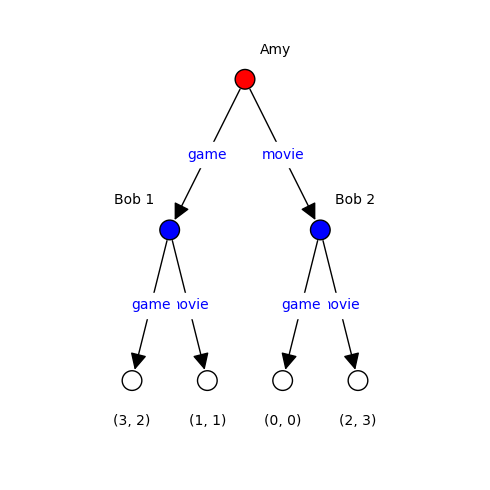

In [5]:
battle.plot(backend="sage")

The `'gtdraw'` backend instead produces a TikZ picture, which is what you want for a paper: it is vector output with real LaTeX typesetting. It returns a picture object whose LaTeX source you can paste into a document, and which can also be rendered to PDF, SVG or PNG.
Rendering compiles the source, so it needs a LaTeX installation on the kernel's `PATH` (`pdflatex`), plus `pdftocairo` from poppler for SVG and PNG. The cell below checks for both and skips the rendering if they are missing; `picture.content()` is the full source either way.

In [6]:
picture = battle.plot(backend="gtdraw")
print("\n".join(picture.content().splitlines()[:6]))

% TikZ code with built-in styling for game trees
% TikZ libraries required for game trees
\usetikzlibrary{shapes}
\usetikzlibrary{arrows.meta}

% Style settings for game tree formatting


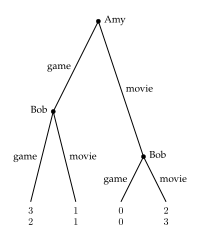

In [7]:
from shutil import which

from IPython.display import SVG

if which("pdflatex") and which("pdftocairo"):
    display(SVG(filename=picture.svg(view=False)))
else:
    print("pdflatex and pdftocairo are not both on PATH; skipping the rendering.")

## Information sets

Now suppose Amy and Bob choose *simultaneously*. The tree is the same shape, but Bob no longer knows which branch he is in: his two nodes have to be bundled into a single information set.

`append_infoset` does that. Instead of giving Bob a fresh move at the second node, we say that the node belongs to the same information set as an existing one.

In [8]:
simultaneous = ExtensiveFormGame(players=["Amy", "Bob"])
simultaneous.append_move(simultaneous.root, "Amy", ["game", "movie"])
simultaneous.append_move(simultaneous.root.children["game"], "Bob",
                         ["game", "movie"])
simultaneous.append_infoset(simultaneous.root.children["movie"],
                            simultaneous.root.children["game"])

for (amy, bob), payoff in payoffs.items():
    simultaneous.set_outcome(simultaneous.root.children[amy].children[bob],
                             f"{amy},{bob}", payoff)

len(simultaneous.infosets), sorted(len(list(s.members))
                                   for s in simultaneous.infosets)

(2, [1, 2])

Two information sets now, one of which contains two nodes. Sage can also confirm that the game has perfect recall, meaning no player ever forgets something they previously knew — an assumption every one of Gambit's solvers relies on.

In [9]:
simultaneous.is_perfect_recall

True

That single change to the information structure changes the answer.
`obtain_nash` sends the game to a Gambit solver and hands back one profile per equilibrium; we read off what each is worth to each player, exactly, with `QQ`.

In [10]:
def payoff_table(game, equilibria):
    return [[QQ(eq.payoff(player)) for player in game.players]
            for eq in equilibria]


print("sequential  ", payoff_table(battle,
                                   battle.obtain_nash(algorithm="enumpure")))
print("simultaneous", payoff_table(simultaneous,
                                   simultaneous.obtain_nash(algorithm="enumpure")))

sequential   [[3, 2], [3, 2], [2, 3]]
simultaneous [[3, 2], [2, 3]]


When Bob moves second he can condition on Amy's choice, and there are three pure equilibria (two of which end at the same outcome). When the players move simultaneously, only two survive.

### Behaviour and mixed strategy profiles

By default the solvers work directly on the tree, and an equilibrium comes back as a **behavior profile**: it gives, for every action, the probability of playing it *conditional on reaching that information set*. Index it by an action, an information set or a player.

Passing `use_strategic=True` solves the reduced strategic form instead, and an equilibrium comes back as a **mixed strategy profile** over complete contingent plans. The two are indexed differently and are not interchangeable — indexing one the way you would index the other raises a `TypeError`.

In [11]:
behavior = battle.obtain_nash(algorithm="enumpure")[0]
mixed = battle.obtain_nash(algorithm="enumpure", use_strategic=True)[0]

game = battle._gambit_()
print("behavior, by action  ", [QQ(behavior[a]) for a in game.actions])
print("mixed, by strategy   ", [QQ(mixed[s]) for s in game.players["Bob"].strategies])

behavior, by action   [1, 0, 1, 0, 1, 0]
mixed, by strategy    [1, 0, 0, 0]


The choice of algorithm is separate. `'lcp'` is the default for a game with at most two players and `'enumpoly'` for more; `'lp'` (constant sum, two players), `'enumpure'`, `'logit'` and `'liap'` are also available.

As in the strategic form, `obtain_nash` answers with exact rationals by default. `'lcp'` and `'lp'` are asked to compute exactly throughout, while the numerical solvers compute in floating point and have their answer rounded to the exact equilibrium it approximates, once Gambit has confirmed in exact arithmetic that it is one. `rational=False` returns the raw floating point answer, and `tolerance` controls how far a probability may be moved to be rounded.

In [12]:
for rational in [True, False]:
    equilibria = battle.obtain_nash(algorithm="logit", rational=rational)
    print(f"rational={str(rational):5s}",
          [[QQ(eq[a]) if rational else eq[a] for a in game.actions]
           for eq in equilibria])

rational=True  [[1, 0, 1, 0, 0, 1]]
rational=False [[0.9999999867182776, 1.3281724096823341e-08, 0.999999986718284, 1.3281717697986011e-08, 2.342948554313063e-24, 1.0]]


## Chance moves

Real games often start with a deal, a roll, or some other move by nature. `append_chance_move` adds one. Its probabilities are optional and default to a uniform distribution over the actions, held exactly; `set_chance_probs` changes them afterwards.

Here is a miniature poker game. Nature deals Alice a high or low card. Alice sees it and either bets or checks. Bob does *not* see the card — his two nodes go into one information set — and either calls or folds.

Two of the leaves award the same payoffs, namely those where Bob folds. Giving `set_outcome` an outcome the game already has, rather than a label and a fresh list of payoffs, awards that same outcome at another leaf instead of creating a duplicate.

In [13]:
poker = ExtensiveFormGame(players=["Alice", "Bob"])
poker.append_chance_move(poker.root, ["High", "Low"])

for card in ["High", "Low"]:
    poker.append_move(poker.root.children[card], "Alice", ["bet", "check"])

poker.append_move(poker.root.children["High"].children["bet"], "Bob",
                  ["call", "fold"])
poker.append_infoset(poker.root.children["Low"].children["bet"],
                     poker.root.children["High"].children["bet"])

poker.set_outcome(poker.root.children["High"].children["bet"].children["call"],
                  "High,bet,call", [2, -2])
poker.set_outcome(poker.root.children["Low"].children["bet"].children["call"],
                  "Low,bet,call", [-2, 2])

poker.set_outcome(poker.root.children["High"].children["bet"].children["fold"],
                  "Bob folds", [1, -1])
poker.set_outcome(poker.root.children["Low"].children["bet"].children["fold"],
                  "Bob folds")

poker.set_outcome(poker.root.children["High"].children["check"],
                  "High,check", [1, -1])
poker.set_outcome(poker.root.children["Low"].children["check"],
                  "Low,check", [-1, 1])

[str(action.prob) for action in poker.root.infoset.actions], len(poker.outcomes)

(['1/2', '1/2'], 5)

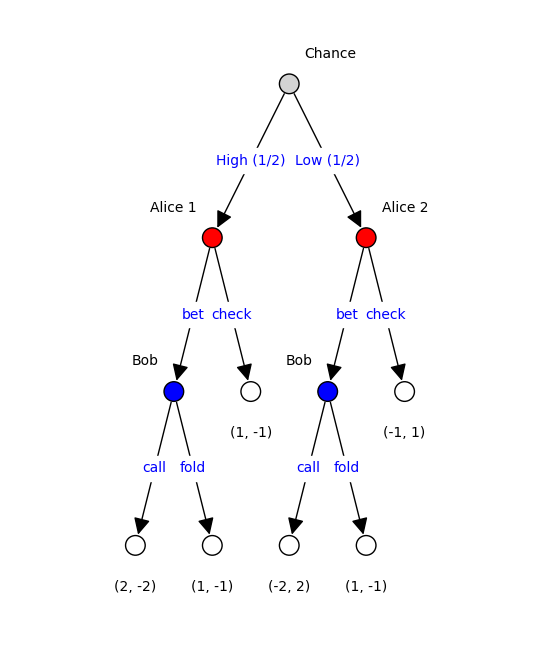

In [14]:
poker.plot(backend="sage")

Alice knows her card and Bob does not, so this is a game of incomplete information — and its equilibrium involves bluffing. Because the chance probabilities are exact rationals and `'lcp'` computes exactly, the answer is exact too.

In [15]:
equilibrium = poker.obtain_nash()[0]
game = poker._gambit_()

with_high, with_low = game.players["Alice"].infosets
bob_infoset, = game.players["Bob"].infosets

{"Alice bets holding High": QQ(equilibrium[with_high.actions["bet"]]),
 "Alice bets holding Low (a bluff)": QQ(equilibrium[with_low.actions["bet"]]),
 "Bob calls": QQ(equilibrium[bob_infoset.actions["call"]])}

{'Alice bets holding High': 1,
 'Alice bets holding Low (a bluff)': 1/3,
 'Bob calls': 2/3}

Alice always bets with a high card, bluffs with a low card exactly one third of the time, and Bob calls two thirds of the time. The game is worth `1/3` to Alice:

In [16]:
QQ(equilibrium.payoff(game.players["Alice"]))

1/3

## Editing a tree

A tree does not have to be built strictly from the root down. `insert_move` puts a new move immediately *above* an existing node, pushing the subtree below it down a level, and `delete_tree` removes everything below a node, turning it back into a leaf.

Here Bob gets a chance to walk away before Alice moves at all, and then the branch in which he plays is cut back off.

In [17]:
def describe(game, note):
    root = game.root.infoset
    leaves = sum(1 for node in game._gambit_().nodes if node.is_terminal)
    print(f"{note:18s} root: {root.player.label:5s} "
          f"{[action.label for action in root.actions]}, {leaves} leaves")


editable = ExtensiveFormGame(players=["Alice", "Bob"])
editable.append_move(editable.root, "Alice", ["L", "R"])
editable.set_outcome(editable.root.children["L"], "L", [2, 5])
editable.set_outcome(editable.root.children["R"], "R", [3, 1])
describe(editable, "as built")

editable.insert_move(editable.root, "Bob", ["play", "walk"])
describe(editable, "after insert_move")

editable.delete_tree(editable.root.children["play"])
describe(editable, "after delete_tree")

as built           root: Alice ['L', 'R'], 2 leaves
after insert_move  root: Bob   ['play', 'walk'], 3 leaves
after delete_tree  root: Bob   ['play', 'walk'], 2 leaves


## Moving games between Sage and Gambit

An `ExtensiveFormGame` can also wrap a tree game you already built with PyGambit. The wrapper does not copy anything — `_gambit_` hands back the very same object, so the two views stay in sync.

In [18]:
tree = gbt.Game.new_tree(players=["Alice", "Bob"], title="tiny")
tree.append_move(tree.root, tree.players["Alice"], ["L", "R"])
for leaf, label, payoff in zip(tree.root.children, ["L", "R"],
                              [[2, 5], [3, 1]], strict=True):
    tree.set_outcome(leaf, tree.add_outcome(label, payoff))

wrapped = ExtensiveFormGame(tree)
wrapped, wrapped._gambit_() is tree

(An extensive form game with 2 players, True)

Games can be written to and read from Gambit's `.efg` format, so a tree built in Sage can be opened in the Gambit GUI and vice versa.
As in the strategic form, `save_efg` writes the game the object holds and so is an ordinary method, while `load_efg` builds a new game from a file and so is a class method.

In [19]:
path = tmp_filename(ext=".efg")
poker.save_efg(path)

reloaded = ExtensiveFormGame.load_efg(path)
reloaded, len(reloaded.infosets)

(An extensive form game with 2 players, 3)

## The game catalog

As in the strategic form case, Gambit's catalog of games from the literature is available directly, through the same pair of class methods. `ExtensiveFormGame.gambit_catalog_games` lists only the tree games, since those are the ones that keep their structure here.

In [20]:
ExtensiveFormGame.gambit_catalog_games(n_players=3)

,Game,Title
0,journals/ijgt/selten1975/fig1,"Selten's horse (Selten IJGT 1975, Figure 1)"
1,journals/ijgt/selten1975/fig3,Selten (IJGT 1975) Figure 3


Selten's horse is the classic example of a Nash equilibrium that is not sequentially rational.

In [21]:
horse = ExtensiveFormGame.load_from_gambit_catalog("journals/ijgt/selten1975/fig1")

horse, payoff_table(horse, horse.obtain_nash(algorithm="enumpure"))

(An extensive form game with 3 players, [[1, 1, 1], [3, 2, 2]])

Both are Nash equilibria, but only one of them survives if you insist that every player behave optimally at every information set they might reach.

The usual tool for ruling out the other one is subgame perfection, and here it is no help at all: only the root begins a subgame, so the game has no *proper* subgames to refine away anything. That is exactly why Selten introduced this example.

In [22]:
[node.is_subgame_root for node in [horse.root,
                                   horse.root.children["L"],
                                   horse.root.children["R"]]]

[True, False, False]

## Case study: the absent-minded driver

Gambit's solvers assume **perfect recall**. When a game violates that assumption they refuse to compute equilibria for it — and they are right to, because the standard theory does not apply.

The best known such game is Piccione and Rubinstein's absent-minded driver. A driver must take the second of two identical exits. The two junctions look exactly the same, so they lie in one information set, and at each the driver either continues or exits. Since he cannot tell them apart, he cannot condition on which one he is at.

Gilboa's version of the game is in the catalog.

In [23]:
driver = ExtensiveFormGame.load_from_gambit_catalog("journals/geb/gilboa1997/fig1")

driver, driver.is_perfect_recall, len(driver.infosets)

(An extensive form game with 1 player, False, 1)

One player, one information set, and no perfect recall. Asking for equilibria says so:

In [24]:
try:
    driver.obtain_nash(algorithm="liap")
except RuntimeError as error:
    print(error)

Computing equilibria of games with imperfect recall is not supported.


What we can still do is hand Gambit a *plan* and ask what it is worth. A plan here is a single number: the probability $p$ of continuing at a junction. Gambit evaluates it exactly.

In [25]:
game = driver._gambit_()


def value(p):
    """Expected payoff of continuing with probability ``p`` at each junction."""
    plan = game.mixed_behavior_profile(rational=True)
    plan[game.actions["B"]] = Fraction(str(p))
    plan[game.actions["E"]] = Fraction(str(1 - p))
    return QQ(plan.payoff(game.players["Player 1"]))


[(p, value(p)) for p in [0, 1/4, 1/2, 3/4, 1]]

[(0, 0), (1/4, 13/16), (1/2, 5/4), (3/4, 21/16), (1, 1)]

Gambit evaluates one plan at a time. Sage can recover the whole function.

The value is a polynomial in $p$ of degree two — the driver passes at most two junctions — so five exact sample points are more than enough to reconstruct it by interpolation over `QQ`. No floating point, no curve fitting.

In [26]:
R = QQ["p"]
value_polynomial = R.lagrange_polynomial([(p, value(p))
                                          for p in [0, 1/4, 1/2, 3/4, 1]])
value_polynomial

-3*p^2 + 4*p

With the value function in hand, finding the best plan is calculus, which is exactly what Sage is for.

In [27]:
p = var("p")
expected_value = value_polynomial(p)

critical_points = solve(diff(expected_value, p) == 0, p)
critical_points

[p == (2/3)]

In [28]:
p_star = critical_points[0].rhs()
p_star, expected_value.subs(p=p_star)

(2/3, 4/3)

So the driver's best plan is to continue with probability $2/3$, worth $4/3$ — both exact.

The interesting part is the comparison with $p = 1/3$, the probability at which the driver, reasoning at a junction about what to do *now*, is indifferent between continuing and exiting. That plan is worth only $1$. Planning ahead and reasoning in the moment give genuinely different answers, which is the whole point of the example.

In [29]:
value(1/3), value(p_star)

(1, 4/3)

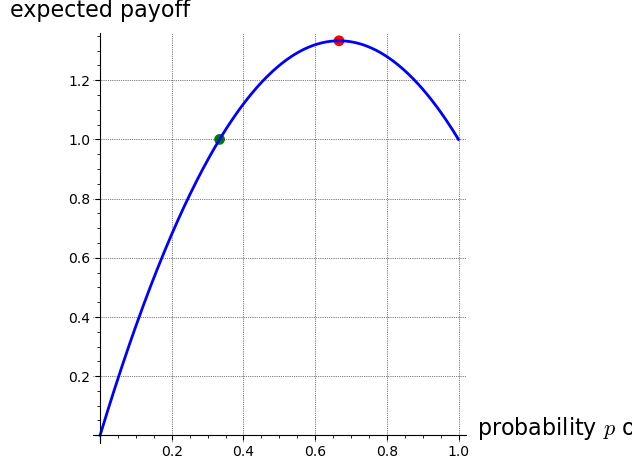

In [30]:
plot(expected_value, (p, 0, 1), thickness=2, gridlines=True,
     axes_labels=["probability $p$ of continuing", "expected payoff"]) \
    + point((p_star, value(p_star)), size=60, color="red") \
    + point((1/3, value(1/3)), size=60, color="green")

The red point is the optimal plan, the green one the point of indifference at a junction.

Gambit evaluated the plans; Sage found the function behind them and optimised it. Neither step works without the other.

## Summary

| Task | Call |
|---|---|
| New tree | `ExtensiveFormGame(players=[...])` |
| Wrap a PyGambit tree | `ExtensiveFormGame(game)` |
| Add a move | `game.append_move(node, player, actions)` |
| Add a move by chance | `game.append_chance_move(node, actions, probs)` |
| Change chance probabilities | `game.set_chance_probs(node, probs)` |
| Bundle nodes into one information set | `game.append_infoset(node, like)` |
| Attach payoffs | `game.set_outcome(node, label, payoffs)` |
| Award an existing outcome again | `game.set_outcome(node, outcome)` |
| Insert a move above a node | `game.insert_move(node, player, actions)` |
| Cut a subtree | `game.delete_tree(node)` |
| Navigate | `game.root.children['action']` |
| Inspect | `game.players`, `game.infosets`, `game.outcomes` |
| Check the recall assumption | `game.is_perfect_recall` |
| Solve | `game.obtain_nash(algorithm='enumpure')` |
| Solve the reduced strategic form | `game.obtain_nash(use_strategic=True)` |
| Ask for floating point answers | `game.obtain_nash(rational=False)` |
| Draw | `game.plot(backend='sage')`, `game.plot(backend='gtdraw')` |
| Show the tree as text | `game.to_efg()` |
| Read and write `.efg` | `ExtensiveFormGame.load_efg(path)`, `game.save_efg(path)` |
| Browse the catalog | `ExtensiveFormGame.gambit_catalog_games()` |
| Load a catalog game | `ExtensiveFormGame.load_from_gambit_catalog(slug)` |

Further reading:

- [SageMath game theory reference](https://doc.sagemath.org/html/en/reference/game_theory/index.html)
- [PyGambit API documentation](https://gambitproject.readthedocs.io/en/latest/pygambit.api.html)
- [Gambit's own extensive form tutorial](../02_extensive_form.ipynb)